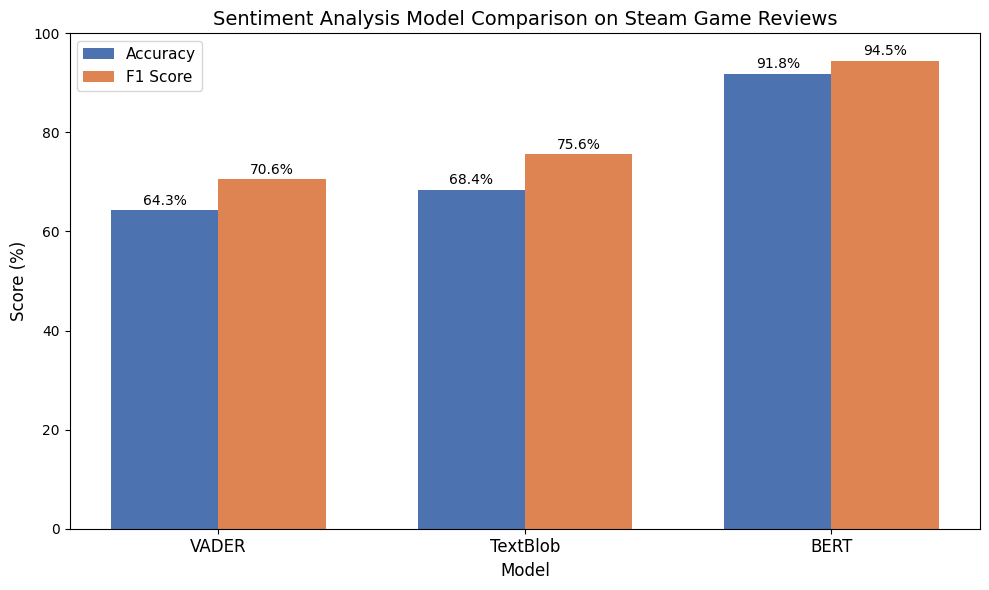

Chart saved!


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Your results
models = ['VADER', 'TextBlob', 'BERT']
accuracy = [64.3, 68.4, 91.8]
f1_scores = [70.6, 75.6, 94.5]

# Create comparison bar chart
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='#DD8452')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Sentiment Analysis Model Comparison on Steam Game Reviews', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/nihalsingh/Desktop/thesis/notebooks/model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved!')


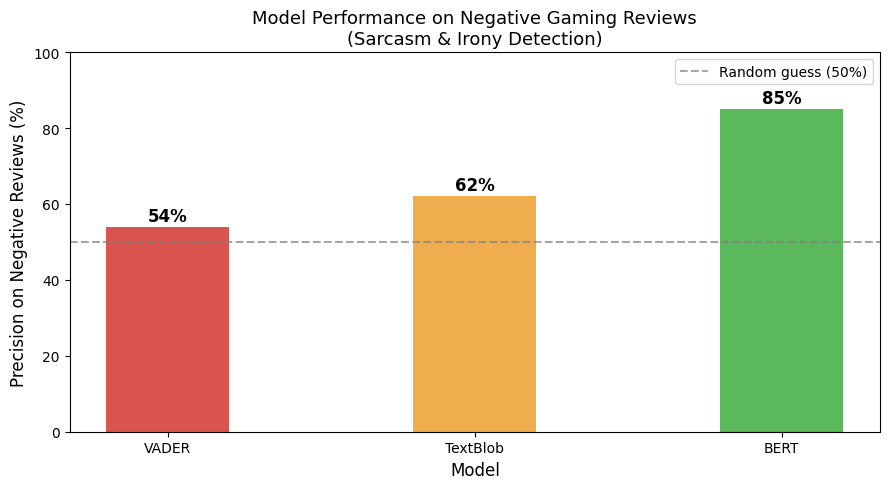

Chart saved!


In [3]:
# Negative review performance comparison
models = ['VADER', 'TextBlob', 'BERT']
negative_precision = [54, 62, 85]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, negative_precision, color=['#d9534f', '#f0ad4e', '#5cb85c'], width=0.4)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Precision on Negative Reviews (%)', fontsize=12)
ax.set_title('Model Performance on Negative Gaming Reviews\n(Sarcasm & Irony Detection)', fontsize=13)
ax.set_ylim(0, 100)

# Add value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add coin flip reference line
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='Random guess (50%)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/Users/nihalsingh/Desktop/thesis/notebooks/negative_review_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved!')

In [5]:
import pandas as pd
from sqlalchemy import create_engine
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

engine = create_engine('postgresql://localhost/steam_analytics')
df_examples = pd.read_sql("""
    SELECT review_text, is_recommended, hours_played
    FROM reviews
    WHERE is_recommended = False
    AND hours_played > 200
    LIMIT 500
""", engine)

analyzer = SentimentIntensityAnalyzer()
df_examples['vader_score'] = df_examples['review_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
df_examples['vader_wrong'] = df_examples['vader_score'] > 0.05

# Show cases where VADER thinks negative review is positive
wrong = df_examples[df_examples['vader_wrong'] == True].head(5)
for i, row in wrong.iterrows():
    print(f"Hours played: {row['hours_played']}")
    print(f"Actually: Negative review")
    print(f"VADER score: {row['vader_score']:.3f} (VADER says: Positive)")
    print(f"Review: {row['review_text'][:200]}")
    print("---")

Hours played: 247.8
Actually: Negative review
VADER score: 0.440 (VADER says: Positive)
Review: 2023 It's a major disappointment, considering they removed the better half of the game. It just leaves you hanging just before the open world part of the game would begin, which had a better story. No
---
Hours played: 763.7
Actually: Negative review
VADER score: 0.994 (VADER says: Positive)
Review: 2022 While i thumbs down this game it is not because the game isn't a good port. i thumbs it down because i dislike the fact Square is borrowing aspects from their prior games such as FF13's stagger s
---
Hours played: 314.1
Actually: Negative review
VADER score: 0.991 (VADER says: Positive)
Review: The story was so much garbage I started holding triangle (skip) during the cut scenes. If you are in any way buying this game to relive it story wise, with the expectation that it can not be so bad th
---
Hours played: 507.9
Actually: Negative review
VADER score: 0.999 (VADER says: Positive)
Review: 2